<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/42_Classification_Evaluation_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분류 평가 지표 실습: TSLA 방향성 예측으로 이해하는 Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix
**Notebook:** `TSLA_Classification_Evaluation_Metrics.ipynb`  
**실행 환경:** Google Colab 권장

---

## 실습 목표
이 실습에서는 **테슬라(TSLA) 주가 데이터**를 이용해  
다음 날 수익률의 **상승/하락 방향**을 분류하는 간단한 모델을 만들고,  
분류 성능을 다양한 평가 지표로 측정하는 방법을 학습합니다.

### 이번 실습에서 다루는 분류 평가 지표
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

---

## 예측 문제 정의
이번 실습의 목표는 다음과 같습니다.

- **내일 수익률이 0보다 크면 → 1 (상승)**
- **내일 수익률이 0 이하이면 → 0 (하락 또는 비상승)**

즉,  
연속값 예측(regression)이 아니라  
**이진 분류(binary classification)** 문제로 바꾸어 평가합니다.

---

## 실습 흐름
1. TSLA 데이터 다운로드
2. 수익률 계산
3. 상승/하락 라벨 생성
4. lag feature 생성
5. train / test 분할
6. Logistic Regression 학습
7. 예측 클래스와 예측 확률 생성
8. Accuracy, Precision, Recall, F1-score 계산
9. ROC-AUC 계산
10. Confusion Matrix 시각화
11. 결과 해석

---

## 핵심 메시지
분류 모델은 단순히 “몇 개 맞췄는가”만으로 평가하면 부족합니다.

- Accuracy: 전체적으로 얼마나 맞췄는가
- Precision: 양성으로 예측한 것 중 실제 양성은 얼마나 되는가
- Recall: 실제 양성을 얼마나 놓치지 않았는가
- F1-score: Precision과 Recall의 균형
- ROC-AUC: 확률 예측의 분리 능력
- Confusion Matrix: 어떤 종류의 오분류가 발생했는지

즉, **분류 평가는 여러 관점에서 함께 봐야 합니다.**


In [1]:
# ============================================
# 1. 필수 라이브러리 설치 및 불러오기
# ============================================

try:
    import yfinance as yf
except ImportError:
    !pip -q install yfinance
    import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. TSLA 데이터 다운로드

이번 실습에서는 Yahoo Finance에서 TSLA 데이터를 다운로드합니다.

### 왜 TSLA를 사용하는가?
- 데이터 접근이 쉽습니다.
- 방향성 예측 문제를 만들기에 적합합니다.
- 상승/하락 분류를 설명하기 직관적입니다.


In [2]:
# ============================================
# 2. TSLA 데이터 다운로드
# ============================================

ticker = "TSLA"
start_date = "2019-01-01"
end_date = "2025-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)

print("Downloaded shape:", df.shape)
display(df.head())


Downloaded shape: (1510, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2019-01-02,20.674667,20.674667,21.008667,19.920000,20.406668,174879000
2019-01-03,20.024000,20.024000,20.626667,19.825333,20.466667,104478000
2019-01-04,21.179333,21.179333,21.200001,20.181999,20.400000,110911500
2019-01-07,22.330667,22.330667,22.449333,21.183332,21.448000,113268000
2019-01-08,22.356667,22.356667,22.934000,21.801332,22.797333,105127500


## 2. MultiIndex-safe 종가 추출

`yfinance`는 환경에 따라 컬럼이 MultiIndex일 수 있으므로,  
항상 안전하게 종가를 추출하는 방식을 사용합니다.


In [3]:
# ============================================
# 3. MultiIndex-safe 종가 추출
# ============================================

def get_close_series(dataframe, ticker_symbol):
    if isinstance(dataframe.columns, pd.MultiIndex):
        return dataframe[("Close", ticker_symbol)].copy()
    return dataframe["Close"].copy()

close_price = get_close_series(df, ticker)
close_price.name = "Close"

display(close_price.head())


,Close
Date,
2019-01-02,20.674667
2019-01-03,20.024000
2019-01-04,21.179333
2019-01-07,22.330667
2019-01-08,22.356667


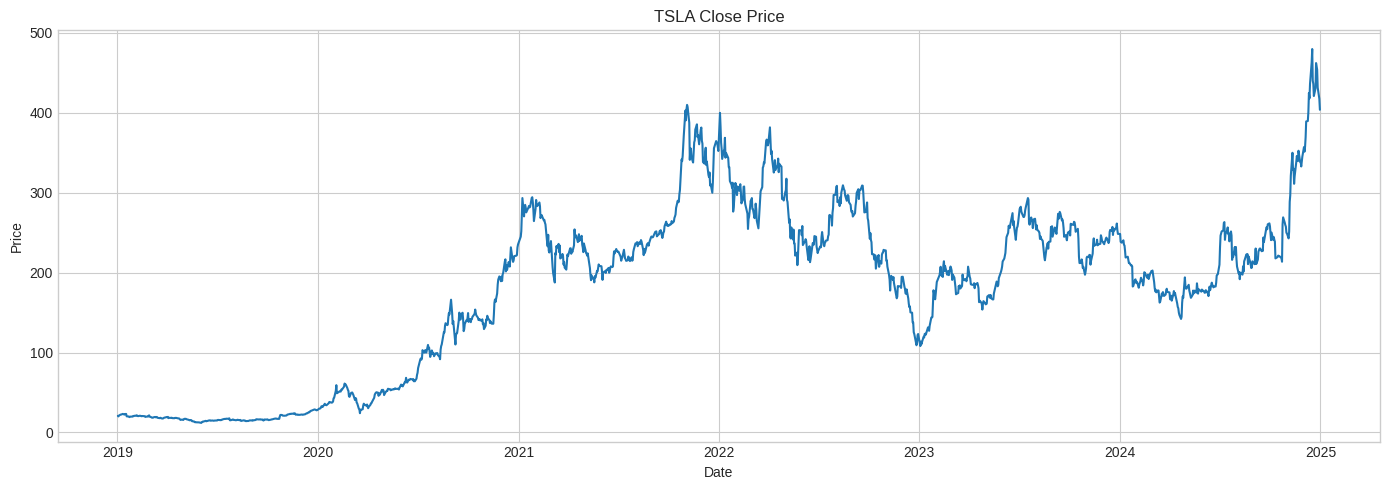

In [4]:
# ============================================
# 4. TSLA 종가 시각화
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(close_price.index, close_price, linewidth=1.5)
plt.title("TSLA Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 3. 수익률 계산과 분류 라벨 만들기

이번 실습에서는 종가로부터 일별 수익률을 계산한 뒤,  
그 수익률이 양수인지 아닌지에 따라 라벨을 만듭니다.

### 라벨 정의
- `1`: 다음 날 수익률 > 0
- `0`: 다음 날 수익률 ≤ 0

이렇게 하면  
“내일 주가 방향이 상승인가 하락인가”를 맞히는 문제로 바뀝니다.


In [5]:
# ============================================
# 5. 수익률 계산
# ============================================

data = pd.DataFrame(index=close_price.index)
data["Close"] = close_price
data["Return"] = data["Close"].pct_change()

display(data.head(10))


,Close,Return
Date,,
2019-01-02,20.674667,NaN
2019-01-03,20.024000,-0.031472
2019-01-04,21.179333,0.057697
2019-01-07,22.330667,0.054361
2019-01-08,22.356667,0.001164
2019-01-09,22.568666,0.009483
2019-01-10,22.997999,0.019023
2019-01-11,23.150667,0.006638
2019-01-14,22.293333,-0.037033


In [6]:
# ============================================
# 6. 다음 날 방향성 라벨 생성
# ============================================

data["Target_Next_Return"] = data["Return"].shift(-1)
data["Target_Class"] = (data["Target_Next_Return"] > 0).astype(int)

display(data[["Return", "Target_Next_Return", "Target_Class"]].head(10))


,Return,Target_Next_Return,Target_Class
Date,,,
2019-01-02,NaN,-0.031472,0
2019-01-03,-0.031472,0.057697,1
2019-01-04,0.057697,0.054361,1
2019-01-07,0.054361,0.001164,1
2019-01-08,0.001164,0.009483,1
2019-01-09,0.009483,0.019023,1
2019-01-10,0.019023,0.006638,1
2019-01-11,0.006638,-0.037033,0
2019-01-14,-0.037033,0.029994,1


## 4. Lag feature 생성

머신러닝 분류모형은 시계열의 순서를 자동으로 이해하지 못하므로,  
최근 수익률들을 입력 변수로 만들어야 합니다.

이번 실습에서는 최근 5일 수익률을 사용합니다.


In [7]:
# ============================================
# 7. Lag feature 생성
# ============================================

n_lags = 5

for lag in range(1, n_lags + 1):
    data[f"lag_{lag}"] = data["Return"].shift(lag)

data = data.dropna().copy()

display(data.head())
print("Prepared dataset shape:", data.shape)


,Close,Return,Target_Next_Return,Target_Class,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,,,,
2019-01-10,22.997999,0.019023,0.006638,1,0.009483,0.001164,0.054361,0.057697,-0.031472
2019-01-11,23.150667,0.006638,-0.037033,0,0.019023,0.009483,0.001164,0.054361,0.057697
2019-01-14,22.293333,-0.037033,0.029994,1,0.006638,0.019023,0.009483,0.001164,0.054361
2019-01-15,22.962000,0.029994,0.004703,1,-0.037033,0.006638,0.019023,0.009483,0.001164
2019-01-16,23.070000,0.004703,0.003641,1,0.029994,-0.037033,0.006638,0.019023,0.009483


Prepared dataset shape: (1503, 9)


## 5. Train / Test 분할

시계열 데이터는 무작위로 섞지 않고  
항상 **과거로 학습하고 미래로 평가**해야 합니다.


In [8]:
# ============================================
# 8. Train / Test split
# ============================================

feature_cols = [f"lag_{i}" for i in range(1, n_lags + 1)]
target_col = "Target_Class"

split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train size:", len(train))
print("Test size :", len(test))
print("Train class balance:")
print(y_train.value_counts(normalize=True))


Train size: 1202
Test size : 301
Train class balance:
Target_Class
1    0.531614
0    0.468386
Name: proportion, dtype: float64


## 6. Logistic Regression 분류모형 학습

이번 실습에서는 가장 기본적인 이진 분류모형인 **Logistic Regression**을 사용합니다.

### 왜 Logistic Regression인가?
- 분류 평가 지표 설명에 가장 적합합니다.
- `predict()`와 `predict_proba()`를 모두 쉽게 해석할 수 있습니다.
- 확률 기반 분류이므로 ROC-AUC 설명도 가능합니다.


In [9]:
# ============================================
# 9. Logistic Regression 학습
# ============================================

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# 최종 분류 결과 (0 또는 1)
test["Predicted_Class"] = clf.predict(X_test)

# 클래스 1(상승)일 확률
test["Predicted_Prob_Up"] = clf.predict_proba(X_test)[:, 1]

display(test[["Target_Class", "Predicted_Class", "Predicted_Prob_Up"]].head(10))


,Target_Class,Predicted_Class,Predicted_Prob_Up
Date,,,
2023-10-19,0,1,0.526532
2023-10-20,1,1,0.513468
2023-10-23,1,1,0.524097
2023-10-24,0,1,0.530725
2023-10-25,0,1,0.536972
2023-10-26,1,1,0.521822
2023-10-27,0,1,0.523993
2023-10-30,1,1,0.528730
2023-10-31,1,1,0.526121


## 7. Accuracy 계산

### Accuracy란?
전체 예측 중에서 **정답 비율**입니다.

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

### 해석
- 가장 직관적인 지표입니다.
- 하지만 클래스 불균형이 심할 때는 misleading할 수 있습니다.

예를 들어,
- 상승 90%, 하락 10% 데이터에서
- 무조건 상승이라고만 예측해도 Accuracy는 높게 나올 수 있습니다.


In [10]:
# ============================================
# 10. Accuracy 계산
# ============================================

acc = accuracy_score(y_test, test["Predicted_Class"])
print("Accuracy:", acc)


Accuracy: 0.5182724252491694


## 8. Precision 계산

### Precision이란?
모델이 **상승이라고 예측한 것들 중** 실제로 상승이었던 비율입니다.

\[
Precision = \frac{TP}{TP + FP}
\]

### 해석
- “양성 예측의 신뢰도”에 가깝습니다.
- 상승이라고 말했을 때 얼마나 믿을 수 있는가를 보여줍니다.

### 언제 중요한가?
거짓 양성(False Positive)을 줄이고 싶을 때 중요합니다.


In [11]:
# ============================================
# 11. Precision 계산
# ============================================

prec = precision_score(y_test, test["Predicted_Class"])
print("Precision:", prec)


Precision: 0.5182724252491694


## 9. Recall 계산

### Recall이란?
실제로 상승이었던 날들 중에서  
모델이 **얼마나 많이 상승으로 잘 찾아냈는가**를 뜻합니다.

\[
Recall = \frac{TP}{TP + FN}
\]

### 해석
- 실제 양성을 놓치지 않는 능력입니다.
- 중요한 사건을 놓치면 안 되는 상황에서 중요합니다.

### 언제 중요한가?
거짓 음성(False Negative)을 줄이고 싶을 때 중요합니다.


In [12]:
# ============================================
# 12. Recall 계산
# ============================================

rec = recall_score(y_test, test["Predicted_Class"])
print("Recall:", rec)


Recall: 1.0


## 10. F1-score 계산

### F1-score란?
Precision과 Recall의 **조화평균**입니다.

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

### 해석
- Precision만 높고 Recall이 낮아도 좋지 않습니다.
- Recall만 높고 Precision이 낮아도 좋지 않습니다.
- 둘의 균형을 보고 싶을 때 F1-score를 사용합니다.


In [13]:
# ============================================
# 13. F1-score 계산
# ============================================

f1 = f1_score(y_test, test["Predicted_Class"])
print("F1-score:", f1)


F1-score: 0.6827133479212254


## 11. ROC-AUC 계산

### ROC-AUC란?
ROC-AUC는 확률 예측이 **상승과 하락을 얼마나 잘 구분하는가**를 나타냅니다.

중요한 점은,
- Accuracy는 최종 0/1 분류 결과를 보지만
- ROC-AUC는 **예측 확률의 분리 능력**을 봅니다.

### 해석 기준
- 0.5: 거의 무작위
- 1.0: 완벽한 분류
- 값이 클수록 클래스 분리 능력이 좋음


In [14]:
# ============================================
# 14. ROC-AUC 계산
# ============================================

auc = roc_auc_score(y_test, test["Predicted_Prob_Up"])
print("ROC-AUC:", auc)


ROC-AUC: 0.4990716180371353


## 12. Confusion Matrix 계산

Confusion Matrix는 분류 결과를 2×2 표로 정리한 것입니다.

### 구성 요소
- **TP (True Positive)**: 실제 상승, 예측도 상승
- **TN (True Negative)**: 실제 하락, 예측도 하락
- **FP (False Positive)**: 실제 하락인데 상승이라고 예측
- **FN (False Negative)**: 실제 상승인데 하락이라고 예측

이 표를 보면  
모델이 **어떤 종류의 실수**를 많이 하는지 알 수 있습니다.


In [15]:
# ============================================
# 15. Confusion Matrix 계산
# ============================================

cm = confusion_matrix(y_test, test["Predicted_Class"])
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[  0 145]
 [  0 156]]


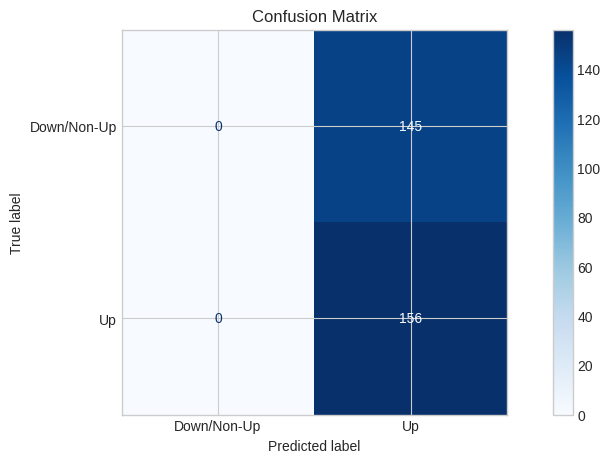

In [16]:
# ============================================
# 16. Confusion Matrix 시각화
# ============================================

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down/Non-Up", "Up"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


## 13. ROC Curve 시각화

ROC Curve는 threshold를 바꾸어 가며  
True Positive Rate와 False Positive Rate 관계를 보여줍니다.

### 해석 포인트
- 곡선이 왼쪽 위에 가까울수록 좋습니다.
- 대각선에 가까우면 무작위 분류와 비슷합니다.


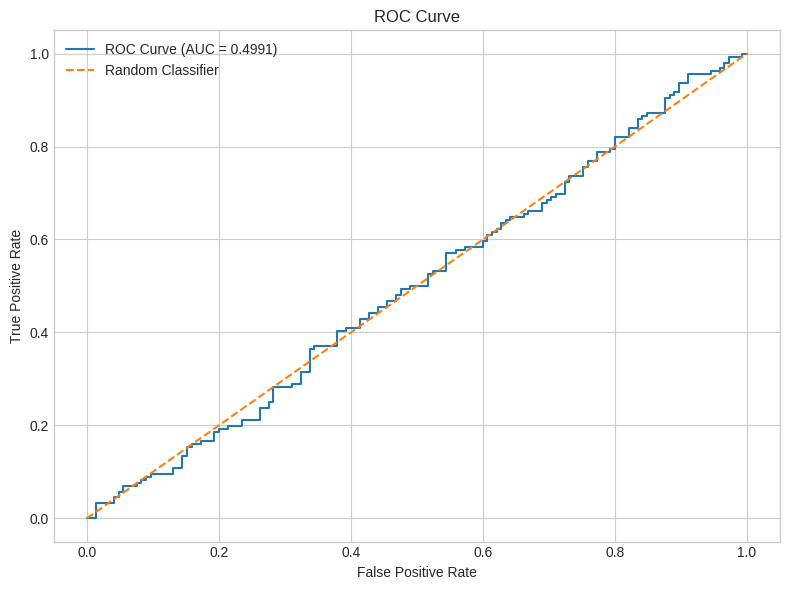

In [17]:
# ============================================
# 17. ROC Curve 시각화
# ============================================

fpr, tpr, thresholds = roc_curve(y_test, test["Predicted_Prob_Up"])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


## 14. 모든 분류 평가 지표를 한 번에 정리

이제 Accuracy, Precision, Recall, F1-score, ROC-AUC를 표로 정리합니다.


In [18]:
# ============================================
# 18. 분류 지표 요약표
# ============================================

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [acc, prec, rec, f1, auc]
})

display(metrics_df)


,Metric,Value
0,Accuracy,0.518272
1,Precision,0.518272
2,Recall,1.000000
3,F1-score,0.682713
4,ROC-AUC,0.499072


In [19]:
# ============================================
# 19. 보기 좋은 형식으로 출력
# ============================================

formatted = metrics_df.copy()
formatted["Value"] = formatted["Value"].apply(lambda x: f"{x:.4f}")
display(formatted)


,Metric,Value
0,Accuracy,0.5183
1,Precision,0.5183
2,Recall,1.0000
3,F1-score,0.6827
4,ROC-AUC,0.4991


## 15. 지표별 해석 정리

### Accuracy
- 전체적으로 얼마나 맞췄는가
- 가장 직관적이지만 불균형 데이터에 약할 수 있음

### Precision
- 상승이라고 예측한 것 중 실제 상승 비율
- 양성 예측의 신뢰도

### Recall
- 실제 상승을 얼마나 놓치지 않았는가
- 중요한 양성 이벤트를 포착하는 능력

### F1-score
- Precision과 Recall의 균형
- 한쪽만 높은 모델을 걸러내는 데 유용

### ROC-AUC
- 확률 기반 분리 능력
- threshold에 덜 민감한 비교 지표

### Confusion Matrix
- 어떤 오분류가 발생했는지 보여줌
- 실무 해석에 매우 중요


## 16. 분류 지표의 장단점 요약표


In [20]:
# ============================================
# 20. 분류 지표 장단점 요약표
# ============================================

summary_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Confusion Matrix"],
    "Strength": [
        "가장 직관적인 전체 정답률",
        "양성 예측의 신뢰도 파악",
        "실제 양성 포착 능력 확인",
        "Precision-Recall 균형 평가",
        "확률 예측의 분리 능력 평가",
        "오분류 구조를 구체적으로 확인"
    ],
    "Weakness": [
        "불균형 데이터에서 왜곡 가능",
        "Recall이 낮아도 높게 나올 수 있음",
        "Precision이 낮아도 높게 나올 수 있음",
        "직관성은 Accuracy보다 낮음",
        "실무 사용자에게 해석이 다소 추상적일 수 있음",
        "숫자 하나로 요약되지 않음"
    ]
})

display(summary_table)


,Metric,Strength,Weakness
0,Accuracy,가장 직관적인 전체 정답률,불균형 데이터에서 왜곡 가능
1,Precision,양성 예측의 신뢰도 파악,Recall이 낮아도 높게 나올 수 있음
2,Recall,실제 양성 포착 능력 확인,Precision이 낮아도 높게 나올 수 있음
3,F1-score,Precision-Recall 균형 평가,직관성은 Accuracy보다 낮음
4,ROC-AUC,확률 예측의 분리 능력 평가,실무 사용자에게 해석이 다소 추상적일 수 있음
5,Confusion Matrix,오분류 구조를 구체적으로 확인,숫자 하나로 요약되지 않음


## 17. 어떤 지표를 더 중요하게 봐야 할까?

정답은 **문제의 목적에 따라 다르다**입니다.

### 예시
- 거짓 양성(FP)을 줄이고 싶다 → **Precision**
- 실제 양성을 놓치면 안 된다 → **Recall**
- 두 지표를 균형 있게 보고 싶다 → **F1-score**
- 전체적인 분리 능력을 보고 싶다 → **ROC-AUC**
- 오분류 패턴을 구체적으로 보고 싶다 → **Confusion Matrix**

즉,  
분류 평가도 하나의 지표만으로 결론 내리기보다  
**여러 지표를 함께 해석**해야 합니다.


## 18. 최종 정리

이번 실습에서 우리는 TSLA 데이터를 사용해  
다음 날 주가 방향을 **상승(1) / 하락(0)** 으로 분류하는 문제를 만들고,  
다음 평가 지표를 계산했습니다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

### 핵심 결론
좋은 분류모형은 단순히 많이 맞히는 것만이 아니라,
- 양성 예측이 얼마나 믿을 만한지
- 실제 양성을 얼마나 놓치지 않는지
- 확률 예측이 얼마나 잘 분리하는지
를 함께 보아야 합니다.


## 19. 연습문제 (Exercises)

1. Logistic Regression 대신 `RandomForestClassifier`를 사용하여 같은 지표를 계산해 보세요.
2. 예측 threshold를 0.5가 아니라 0.6, 0.4로 바꾸면 Precision과 Recall이 어떻게 달라지는지 확인해 보세요.
3. TSLA 대신 AAPL, NVDA를 사용하여 Accuracy와 ROC-AUC를 비교해 보세요.
4. lag feature 개수를 5개에서 10개로 늘리면 성능이 어떻게 바뀌는지 확인해 보세요.
5. 실제 투자 상황에서 Precision과 Recall 중 어느 쪽이 더 중요한지 자신의 기준으로 설명해 보세요.
